# Inference Evaluator — Local Models

Evaluate **zero-shot** clinical outcome prediction on your test CSV using:
- Raw : `google/gemma-3-270m` (runs on Apple Silicon **MPS**, CUDA **GPU**, or CPU automatically)
- Raw : `google/medgemma-4b-it` (runs on Apple Silicon **MPS**, CUDA **GPU**, or CPU automatically)
- Fine-tuned : `google/gemma-3-270m` (runs on Apple Silicon **MPS**, CUDA **GPU**, or CPU automatically)
- Knowledge Distilled : `google/gemma-3-270m` (runs on Apple Silicon **MPS**, CUDA **GPU**, or CPU automatically)

Metrics reported: **accuracy**, **macro-F1**, **latency** (mean & p95), and **resource usage** (CPU/RAM client-side).

## 0) Setup
Install dependencies. For Apple Silicon, these CPU wheels enable MPS automatically on macOS ≥ 12.3.

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "true"
!pip install --upgrade pip
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu
!pip install transformers scikit-learn psutil requests tqdm

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu


## 1) Configuration
Set your paths and options here. You can point `TEST_CSV` to any CSV that matches the expected schema.

In [2]:
import os

TEST_CSV = os.getenv("INFER_EVAL_TEST_CSV", "dataset/splits/test.csv")

# Labels to classify (must match values in output_text)
LABELS = ["Stable", "Improved", "Worsened"]

# Models
GEMMA3_MODEL_ID = "google/gemma-3-270m-it"
MED_GEMMA_4B = "google/medgemma-4b-it"

# Inference parameters (deterministic)
GEN_KW = dict(max_new_tokens=2, do_sample=False)

# Optional: limit eval size for quick sanity checks
SAMPLE_LIMIT = None  # e.g., 100 or None for full test set

# Resource sampling interval (seconds)
STATS_INTERVAL = 0.25

print("Config loaded. TEST_CSV=", TEST_CSV)

Config loaded. TEST_CSV= dataset/splits/test.csv


## 2) Imports

In [3]:
import time, json, threading
import psutil
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report

## 3) Data Loading & Prompt Builder
Build a compact clinical vignette per row and a normalizer to map free-form outputs into the fixed label set.

In [4]:
df = pd.read_csv(TEST_CSV)
if SAMPLE_LIMIT is not None:
    df = df.sample(SAMPLE_LIMIT, random_state=0).reset_index(drop=True)

def row_to_prompt(r):
    return (
        f"Patient: {r['patient_sex']}, {int(r['patient_age'])} years old.\n"
        f"Diagnosis: {r['diagnosis']} (ICD-10: {r['icd_code']}).\n"
        f"Treatment: {r['treatment']}.\n"
        f"Comorbidity: {r['comorbidity']}.\n"
        f"Vitals — SBP: {r['systolic_bp']} mmHg, DBP: {r['diastolic_bp']} mmHg, "
        f"Heart Rate: {r['heart_rate']} bpm, Temp: {r['temperature']}°C.\n"
        f"Labs — Glucose: {r['glucose']} mg/dL, Cholesterol: {r['cholesterol']} mg/dL.\n\n"
        f"Question: Based on these findings, predict the clinical outcome.\n"
        f"Answer with one word ONLY from this set: {', '.join(LABELS)}."
    )

prompts = [row_to_prompt(r) for _, r in df.iterrows()]
gold = df["clinical_outcome"].tolist()

def normalize_label(s: str) -> str:
    if not s or not s.strip():
        return "_OTHER_"
    s_low = s.lower()
    for lab in LABELS:
        if lab.lower() in s_low:
            return lab
    parts = s.strip().split()
    if not parts:
        return "_OTHER_"
    first = parts[0].strip(" .,:;").capitalize()
    return first if first in LABELS else "_OTHER_"

len(prompts), prompts[0][:200] + "..."

(2000,
 'Patient: Male, 88 years old.\nDiagnosis: Osteoarthritis (ICD-10: I25).\nTreatment: Dialysis.\nComorbidity: Obesity.\nVitals — SBP: 178 mmHg, DBP: 70 mmHg, Heart Rate: 84 bpm, Temp: 36.9°C.\nLabs — Glucose:...')

## 4) Resource Sampler (CPU/RAM)
Client-side CPU and RAM sampling while inference runs. GPU metrics are omitted for portability.

In [5]:
class ResourceSampler:
    def __init__(self, interval=0.25):
        self.interval = interval
        self._stop = threading.Event()
        self.samples = []

    def _sample_once(self):
        cpu = psutil.cpu_percent(interval=None)
        mem = psutil.virtual_memory().percent
        self.samples.append({"cpu_percent": cpu, "mem_percent": mem})

    def _run(self):
        while not self._stop.is_set():
            self._sample_once()
            time.sleep(self.interval)

    def start(self):
        self._stop.clear()
        self.thread = threading.Thread(target=self._run, daemon=True)
        self.thread.start()

    def stop(self):
        self._stop.set()
        self.thread.join()

    def summary(self):
        if not self.samples:
            return {}
        def max_of(key):
            return max(s.get(key, 0) for s in self.samples)
        def avg_of(key):
            vals = [s.get(key, 0) for s in self.samples]
            return sum(vals)/len(vals) if vals else 0.0
        return {
            "cpu_percent_max": round(max_of("cpu_percent"), 1),
            "cpu_percent_avg": round(avg_of("cpu_percent"), 1),
            "mem_percent_max": round(max_of("mem_percent"), 1),
            "mem_percent_avg": round(avg_of("mem_percent"), 1),
        }


## 5) Inference Module for Gemma-3-270M (MPS/CUDA/CPU)
Automatically uses **MPS** on Apple Silicon, **CUDA** if available, otherwise **CPU**.

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

def inference_gemma3(model_id):
    return eval_local(model_id)

def pick_device():
    if torch.backends.mps.is_available():
        print("⚡ Using Apple Silicon (MPS) acceleration.")
        return torch.device("mps"), torch.float32
    if torch.cuda.is_available():
        print("🟢 Using CUDA GPU.")
        return torch.device("cuda"), torch.float16
    print("🧠 Using CPU.")
    return torch.device("cpu"), torch.float32

def eval_local(model_id):
    device, dtype = pick_device()
    tok = AutoTokenizer.from_pretrained(model_id)
    if tok.pad_token_id is None:
        # many causal LMs use eos as pad
        tok.pad_token = tok.eos_token or tok.unk_token

    model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=dtype)
    model.to(device)
    model.eval()

    # Chat-style generator for Gemma-IT
    def generate_chat(p: str):
        messages = [
            {"role": "system", "content": "You are a medical classifier. Reply with exactly one word from: Stable, Improved, Worsened."},
            {"role": "user", "content": p}
        ]
        chat_text = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tok(chat_text, return_tensors="pt").to(device)

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=2,           # short & deterministic
                min_new_tokens=1,           # ensure at least 1 new token
                do_sample=False,
                use_cache=True,
                pad_token_id=tok.pad_token_id,
                eos_token_id=tok.eos_token_id,
            )

        # decode only what was generated
        in_len = inputs["input_ids"].shape[1]
        seq = out[0]
        new_ids = seq[in_len:] if seq.shape[0] > in_len else seq[0:0]

        text = tok.decode(new_ids, skip_special_tokens=True).strip()

        # Fallbacks: if empty, try decoding the full sequence then strip the prompt prefix
        if not text:
            full = tok.decode(seq, skip_special_tokens=True)
            # best-effort removal of the original chat_text from the front, if present
            text = full[len(chat_text):].strip() if full.startswith(chat_text) else full.strip()

        return text

    # resource sampler
    sampler = ResourceSampler(interval=STATS_INTERVAL)
    sampler.start()
    latencies, predictions = [], []

    t0 = time.time()
    for p in tqdm(prompts, desc=f"Local eval: {model_id}"):
        s = time.time()
        gen_text = generate_chat(p)
        latencies.append(time.time() - s)
        predictions.append(normalize_label(gen_text))

    total = time.time() - t0
    sampler.stop()
    stats = sampler.summary()

    # sanity-check lengths
    if len(predictions) != len(gold):
        raise ValueError(f"Pred/gold mismatch: {len(predictions)} vs {len(gold)}")

    acc = accuracy_score(gold, predictions)
    f1m = f1_score(gold, predictions, average="macro", zero_division=0)
    report = classification_report(gold, predictions, labels=LABELS, zero_division=0)

    print(f"✅ Completed local inference for {model_id}")

    return {
        "model_id": model_id,
        "accuracy": acc,
        "macro_f1": f1m,
        "per_sample_latency_sec_mean": sum(latencies)/len(latencies),
        "per_sample_latency_sec_p95": sorted(latencies)[int(0.95*len(latencies))-1],
        "total_time_sec": total,
        "resource_stats": stats,
        "report": report,
    }


/home/ntnbhat9/Clinical-Result-Prediction-Fine-Tuned-Models/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 7) Evaluation For Low Compute hungry models
Generates the evaluation report for the given model id in the eval_reports folder. Designed to primarily support on-device models , you can use this same technique for inference if you have high GPU power on device. Otherwise use cloud provider to run inference for bigger models.

In [7]:
def fmt_pct(x): return f"{100*x:.2f}%"
def fmt_sec(x): return f"{x:.3f}s"

def summarize(r):
    rs = r.get("resource_stats", {})
    return {
        "model": r["model_id"],
        "accuracy": fmt_pct(r["accuracy"]),
        "macro_f1": fmt_pct(r["macro_f1"]),
        "lat_mean": fmt_sec(r["per_sample_latency_sec_mean"]),
        "lat_p95": fmt_sec(r["per_sample_latency_sec_p95"]),
        "total_time": fmt_sec(r["total_time_sec"]),
        "cpu_max%": rs.get("cpu_percent_max"),
        "ram_max%": rs.get("mem_percent_max"),
    }


def run_evaluation_for_low_resource_models(model_id: str):
    results = inference_gemma3(model_id)
    safe_model_id = model_id.replace("/", "_")
    file_path = f"dataset/eval_reports/{safe_model_id}-inference-gpu-evaluation.json"
    os.makedirs("dataset/eval_reports", exist_ok=True)
    with open(file_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f'Saved detailed JSON to file "{file_path}"')


## 8) Evaluate Gemma3 - Non fine tuned

In [8]:
run_evaluation_for_low_resource_models(MED_GEMMA_4B)

🟢 Using CUDA GPU.


`torch_dtype` is deprecated! Use `dtype` instead!
Local eval: google/medgemma-4b-it: 100%|██████████| 2000/2000 [04:58<00:00,  6.69it/s]


✅ Completed local inference for google/medgemma-4b-it
Saved detailed JSON to file "dataset/eval_reports/google_medgemma-4b-it-inference-gpu-evaluation.json"


## Plot Evaluations

In [9]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [10]:
import matplotlib.pyplot as plt
import json

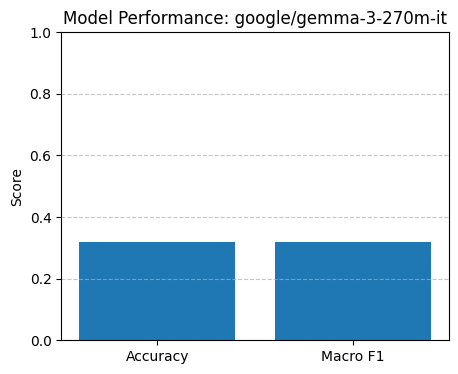

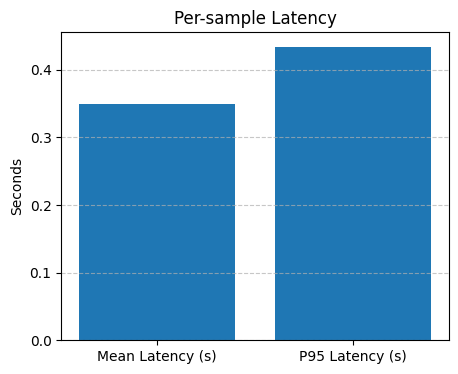

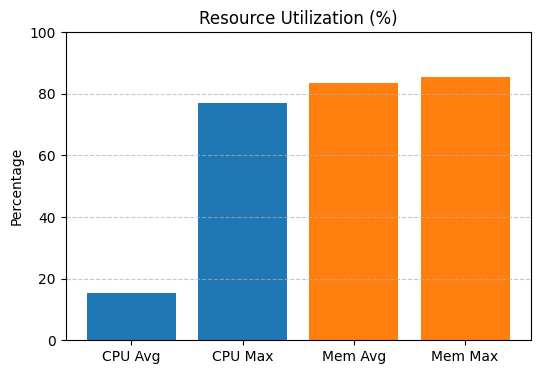

📊 Classification Report:
              precision    recall  f1-score   support

      Stable       0.28      0.31      0.30       632
    Improved       0.33      0.32      0.33       675
    Worsened       0.34      0.33      0.33       693

    accuracy                           0.32      2000
   macro avg       0.32      0.32      0.32      2000
weighted avg       0.32      0.32      0.32      2000



In [11]:
def plot(model_id: str):
    safe_model_id = model_id.replace("/", "_")
    file_path = f"dataset/eval_reports/{safe_model_id}-inference-evaluation.json"
    # --- Load JSON ---
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    with open(file_path, "r") as f:
        data = json.load(f)


    # --- Plot 1: Accuracy and F1 ---
    plt.figure(figsize=(5, 4))
    plt.bar(['Accuracy', 'Macro F1'], [data["accuracy"], data["macro_f1"]])
    plt.title(f'Model Performance: {data["model_id"]}')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- Plot 2: Latency stats ---
    plt.figure(figsize=(5, 4))
    plt.bar(['Mean Latency (s)', 'P95 Latency (s)'],
            [data["per_sample_latency_sec_mean"], data["per_sample_latency_sec_p95"]])
    plt.title('Per-sample Latency')
    plt.ylabel('Seconds')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- Plot 3: Resource usage ---
    resource = data["resource_stats"]
    labels = ['CPU Avg', 'CPU Max', 'Mem Avg', 'Mem Max']
    values = [resource["cpu_percent_avg"], resource["cpu_percent_max"],
              resource["mem_percent_avg"], resource["mem_percent_max"]]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, values, color=['#1f77b4', '#1f77b4', '#ff7f0e', '#ff7f0e'])
    plt.title('Resource Utilization (%)')
    plt.ylabel('Percentage')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- Optional: Print classification report ---
    print("📊 Classification Report:")
    print(data["report"])

plot(GEMMA3_MODEL_ID)